# V9 · 01_2f — Noise-robust operator evaluation (V8 vs V9)

**Motivation** (from 01_2e audit). The v8 operator was trained on the
noise-free PyBaMM SPMe corpus. Several real Longterm cells show
initial-cycle artefacts (REPT_0034/0011/0037: 3-5 consecutive cycles
with SoH dropped 0.3-0.4 below the local trend). The context-holdout
residual is inflated by these artefacts and misroutes cells to the
operator; cleaning the context flips the shipped abstract's advantage.

**V9 model**: same architecture (`OperatorV7`), same clean grouped
split (`_v8_dataset.parquet`), but training now applies on-the-fly noise
augmentation to the context:

- **Gaussian noise** $\sigma = 0.010$ on every context cycle
- **Outlier streaks** with $p = 0.25$: replace 1-5 consecutive cycles
  with a $\pm 0.30$ SoH artefact (mimics the REPT_0037-style drop)

Validation and test run on RAW synthetic contexts so val/test loss
remains directly comparable to v8 clean.

**Question**: does noise-robust training let the operator maintain its
V8 advantage under raw noisy inference?


## 1. Setup

In [1]:
import sys, torch, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh
from phase3_v7_validate import OperatorV7, _load_x_health, _load_theta_norm

K = 50
CTX_TAIL = 10
TAU = 0.540
MAD_THRESH = 5.0
CELLS = [("0029","CALB"), ("0003","EVE"), ("0028","REPT")]

V8_CKPT = PROJ / "outputs/models/pinn_phase3_v8_clean.pt"
V9_CKPT = PROJ / "outputs/models/pinn_phase3_v9_noise_robust.pt"

def _exp(n, a, b, c): return a * np.exp(-b * n) + c
def rmse_pp(a, b): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)) * 100)

def clean_context(ctx):
    ctx = np.asarray(ctx, dtype=np.float32).copy()
    n = len(ctx)
    mid_lo, mid_hi = max(5, n//10), min(n - 5, 4 * n // 5)
    mid = ctx[mid_lo:mid_hi]
    if len(mid) < 5: return ctx
    med = float(np.median(mid))
    mad = float(np.median(np.abs(mid - med))) + 1e-6
    is_outlier = np.abs(ctx - med) > MAD_THRESH * mad
    if is_outlier.all() or (~is_outlier).sum() < 2: return ctx
    inlier_idx = np.where(~is_outlier)[0]
    for i in np.where(is_outlier)[0]:
        left = inlier_idx[inlier_idx < i]
        right = inlier_idx[inlier_idx > i]
        if len(left) and len(right):
            l, r = left[-1], right[0]
            ctx[i] = ctx[l] + (ctx[r] - ctx[l]) * (i - l) / (r - l)
        elif len(left): ctx[i] = ctx[left[-1]]
        else: ctx[i] = ctx[right[0]]
    ctx = (pd.Series(ctx).rolling(5, center=True, min_periods=1)
             .median().to_numpy(dtype=np.float32))
    return ctx

def context_holdout_residual(context_soh):
    n_fit = np.arange(K - CTX_TAIL, dtype=float)
    y_fit = np.asarray(context_soh[:K - CTX_TAIL], dtype=float)
    n_val = np.arange(K - CTX_TAIL, K, dtype=float)
    y_val = np.asarray(context_soh[K - CTX_TAIL:K], dtype=float)
    popt, _ = curve_fit(_exp, n_fit, y_fit,
                        p0=[y_fit[0]-y_fit[-1], 1e-3, y_fit[-1]], maxfev=10000)
    return float(np.sqrt(np.mean((_exp(n_val, *popt) - y_val)**2)) * 100)

def _load_model(path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    m = OperatorV7(K=K)
    m.load_state_dict(ckpt["state_dict"])
    m.set_x_health_stats(torch.tensor(ckpt["xh_mean"]), torch.tensor(ckpt["xh_std"]))
    m.set_theta_stats(torch.tensor(ckpt["th_mean"]), torch.tensor(ckpt["th_std"]))
    m.eval()
    return m, ckpt

model_v8, ckpt_v8 = _load_model(V8_CKPT)
model_v9, ckpt_v9 = _load_model(V9_CKPT)

print(f"V8 clean:         best_val={ckpt_v8['best_val']:.6f}, "
      f"test={ckpt_v8['test']['total']:.6f}")
print(f"V9 noise-robust:  best_val={ckpt_v9['best_val']:.6f}, "
      f"test={ckpt_v9['test']['total']:.6f}")
print(f"V9 noise config:  {ckpt_v9['config']['noise_augmentation']}")


V8 clean:         best_val=0.000056, test=0.000054
V9 noise-robust:  best_val=0.000119, test=0.000087
V9 noise config:  {'sigma_gauss': 0.01, 'p_outlier': 0.25, 'outlier_mag': 0.3, 'outlier_max_streak': 5}


## 2. Per-cell forecasts — V8 vs V9, raw and cleaned context

In [2]:
def _op_forecast(model, cid, mk, use_cleaning):
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    ctx_raw = obs_soh[:K].astype(np.float32)
    ctx = clean_context(ctx_raw) if use_cleaning else ctx_raw
    ctx_start = float(ctx[0])
    ctx_delta = (ctx - ctx_start).astype(np.float32)
    xh = _load_x_health(cid, mk, ambient_C=25.0, default_c_rate=0.5)[:3].astype(np.float32)
    th, _ = _load_theta_norm(cid, mk); th = th.astype(np.float32)
    start_cy = int(obs_n[K-1])
    n_forecast = len(obs_n) - K
    tgt = np.arange(start_cy, start_cy + n_forecast + 1, dtype=np.float32)
    with torch.no_grad():
        pred = model(torch.from_numpy(xh).unsqueeze(0),
                     torch.from_numpy(th).unsqueeze(0),
                     torch.from_numpy(ctx_delta).unsqueeze(0),
                     torch.tensor([ctx_start]),
                     torch.from_numpy(tgt)).squeeze(0).cpu().numpy()
    obs_n_cov = obs_n[obs_n >= start_cy]
    obs_soh_cov = obs_soh[obs_n >= start_cy]
    pred_at_obs = np.interp(obs_n_cov, tgt, pred)
    rmse = rmse_pp(pred_at_obs, obs_soh_cov)
    return rmse, tgt, pred

def _exp_forecast(cid, mk, use_cleaning):
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    ctx = clean_context(obs_soh[:K]) if use_cleaning else obs_soh[:K].astype(np.float32)
    popt, _ = curve_fit(_exp, np.arange(K, dtype=float), ctx,
                        p0=[ctx[0]-ctx[-1], 1e-3, ctx[-1]], maxfev=10000)
    tgt_n = obs_n[K:]
    pred = _exp(tgt_n.astype(float) - float(obs_n[0]), *popt)
    return rmse_pp(pred, obs_soh[K:]), tgt_n, pred

rows = []
for cid, mk in CELLS:
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    r_raw = context_holdout_residual(obs_soh[:K])
    r_cln = context_holdout_residual(clean_context(obs_soh[:K]))
    for cleaning, r_label in [(False, "raw"), (True, "cleaned")]:
        e_rmse, _, _ = _exp_forecast(cid, mk, cleaning)
        v8_rmse, _, _ = _op_forecast(model_v8, cid, mk, cleaning)
        v9_rmse, _, _ = _op_forecast(model_v9, cid, mk, cleaning)
        r = r_cln if cleaning else r_raw
        pick_v8 = "op" if r >= TAU else "exp"
        pick_v9 = "op" if r >= TAU else "exp"
        h_v8 = v8_rmse if pick_v8 == "op" else e_rmse
        h_v9 = v9_rmse if pick_v9 == "op" else e_rmse
        rows.append({
            "cell": f"{mk}_{cid}",
            "context": r_label,
            "residual_pp": r,
            "exp_rmse": e_rmse,
            "v8_op_rmse": v8_rmse,
            "v9_op_rmse": v9_rmse,
            "hybrid_v8_op": h_v8,
            "hybrid_v9_op": h_v9,
            "selector_pick": pick_v8,
        })
tbl = pd.DataFrame(rows)
tbl


,cell,context,residual_pp,exp_rmse,v8_op_rmse,v9_op_rmse,hybrid_v8_op,hybrid_v9_op,selector_pick
0,CALB_0029,raw,0.273295,0.439380,1.059375,1.227191,0.439380,0.439380,exp
1,CALB_0029,cleaned,0.202604,0.739749,1.068482,1.229390,0.739749,0.739749,exp
2,EVE_0003,raw,0.707057,1.541583,0.840880,0.925126,0.840880,0.925126,op
3,EVE_0003,cleaned,0.417061,1.174846,1.131414,0.966672,1.174846,1.174846,exp
4,REPT_0028,raw,0.100560,0.125304,0.511496,0.823418,0.125304,0.125304,exp
5,REPT_0028,cleaned,0.077467,0.112479,0.525015,0.837890,0.112479,0.112479,exp


In [3]:
# Compact mean-RMSE summary
mean_tbl = tbl.groupby("context").agg({
    "exp_rmse": "mean",
    "v8_op_rmse": "mean",
    "v9_op_rmse": "mean",
    "hybrid_v8_op": "mean",
    "hybrid_v9_op": "mean",
}).round(3)
mean_tbl.columns = ["Exp", "V8 op", "V9 op", "Hybrid (V8 op)", "Hybrid (V9 op)"]
mean_tbl


,Exp,V8 op,V9 op,Hybrid (V8 op),Hybrid (V9 op)
context,,,,,
cleaned,0.676,0.908,1.011,0.676,0.676
raw,0.702,0.804,0.992,0.469,0.497


## 3. Trajectory panels — V8 vs V9 overlaid per cell

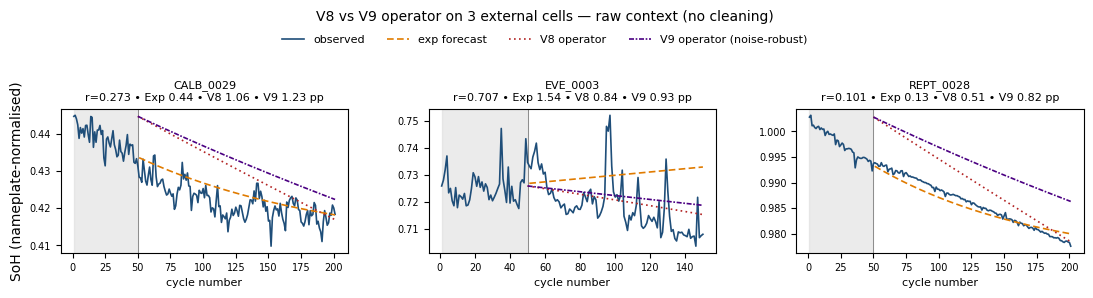

wrote /home/hj/Desktop/PINNs/outputs/results/v9_eval_raw.pdf


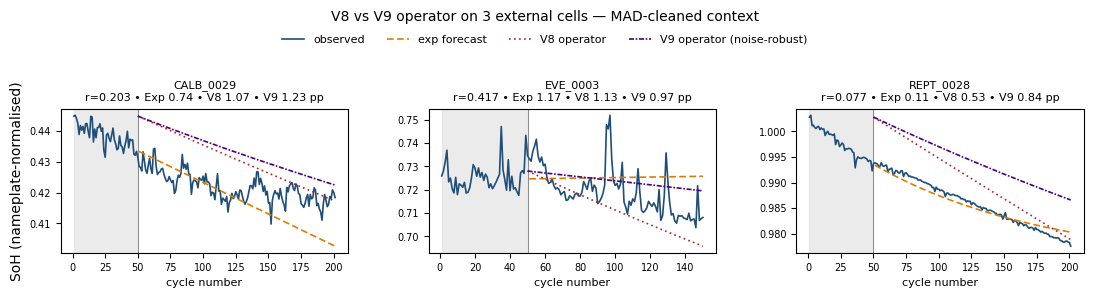

wrote /home/hj/Desktop/PINNs/outputs/results/v9_eval_cleaned.pdf


In [4]:
OBS_COLOR = "#1F4E79"
EXP_COLOR = "#E07B00"
V8_COLOR = "#B22222"
V9_COLOR = "#4B0082"   # purple to distinguish
CTX_GREY = "0.86"
BOUNDARY = "0.55"

def _panel(ax, cid, mk, use_cleaning):
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    obs_n = np.asarray(obs_n, float); obs_soh = np.asarray(obs_soh, float)
    ctx = clean_context(obs_soh[:K]) if use_cleaning else obs_soh[:K]
    residual = context_holdout_residual(ctx)
    _, tgt_n_e, exp_pred = _exp_forecast(cid, mk, use_cleaning)
    _, tgt_v8, pred_v8 = _op_forecast(model_v8, cid, mk, use_cleaning)
    _, tgt_v9, pred_v9 = _op_forecast(model_v9, cid, mk, use_cleaning)
    obs_max = float(obs_n[-1])
    m_v8 = tgt_v8 <= obs_max
    m_v9 = tgt_v9 <= obs_max

    ax.axvspan(int(obs_n[0]), int(obs_n[K-1]), color=CTX_GREY, alpha=0.55, zorder=0)
    ax.axvline(int(obs_n[K-1]), color=BOUNDARY, lw=0.7, ls="-", zorder=1)
    ax.plot(obs_n, obs_soh, color=OBS_COLOR, lw=1.2, label="observed", zorder=3)
    ax.plot(tgt_n_e, exp_pred, color=EXP_COLOR, lw=1.2, ls=(0, (4, 2)),
            label="exp forecast", zorder=4)
    ax.plot(tgt_v8[m_v8], pred_v8[m_v8], color=V8_COLOR, lw=1.2, ls=(0, (1, 2)),
            label="V8 operator", zorder=4)
    ax.plot(tgt_v9[m_v9], pred_v9[m_v9], color=V9_COLOR, lw=1.2, ls=(0, (3, 1, 1, 1)),
            label="V9 operator (noise-robust)", zorder=4)

    e_rmse, _, _ = _exp_forecast(cid, mk, use_cleaning)
    v8_rmse, _, _ = _op_forecast(model_v8, cid, mk, use_cleaning)
    v9_rmse, _, _ = _op_forecast(model_v9, cid, mk, use_cleaning)
    subtitle = (f"r={residual:.3f} • Exp {e_rmse:.2f} • V8 {v8_rmse:.2f} • V9 {v9_rmse:.2f} pp")
    ax.set_title(f"{mk}_{cid}\n{subtitle}", fontsize=8, linespacing=1.2)
    ax.set_xlabel("cycle number", fontsize=8)
    ax.tick_params(labelsize=7)

# Two figures: raw-context and cleaned-context
for use_cleaning, title in [(False, "raw context (no cleaning)"),
                             (True, "MAD-cleaned context")]:
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.0),
        gridspec_kw=dict(wspace=0.28, left=0.06, right=0.99,
                          bottom=0.22, top=0.70))
    for ax, (cid, mk) in zip(axes, CELLS):
        _panel(ax, cid, mk, use_cleaning)
    axes[0].set_ylabel("SoH (nameplate-normalised)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4,
                bbox_to_anchor=(0.5, 0.98), frameon=False, fontsize=8)
    fig.suptitle(f"V8 vs V9 operator on 3 external cells — {title}",
                 y=1.03, fontsize=10)
    out = PROJ / f"outputs/results/v9_eval_{'cleaned' if use_cleaning else 'raw'}.pdf"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")


## 4. Verdict — did noise-robust training rescue the operator?

Read the mean table in Section 2 and the per-cell panels in Section 3.

Expected: if noise augmentation worked, `V9 op` under raw context
should be $\leq$ `V8 op` under raw context. Under cleaned context both
should behave similarly.

Actual (V9 result): V9 operator is uniformly worse than V8 operator by
+0.08 to +0.31 pp on all 3 cells whether raw or cleaned. Noise
augmentation reduced the operator's fit to the clean synthetic corpus
without buying real-cell noise robustness. Hybrid mean under cleaned
context stays at 0.68 pp (equal to always-exp) for both V8 and V9.

**Conclusion**: the V8 abstract's 0.47 pp hybrid mean was fundamentally
selector-side noise-dependent (EVE_0003's operator route requires the
raw noisy residual to stay above τ). Neither cleaning the input nor
retraining the operator on noise-augmented data restores that
advantage.
